In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
df = pd.read_csv('../data/processed/telco_cleaned.csv')

# ✅ Keep customerID separately before dropping for modeling
customer_ids = df['customerID'].copy()

# Drop customerID for modeling only
df_model = df.drop('customerID', axis=1)

print(f"Shape: {df_model.shape}")
print(f"Columns: {list(df_model.columns)}")


Shape: (7043, 21)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Binary']


In [3]:
target = 'Churn_Binary'

# Get all categorical columns for encoding (exclude Churn label)
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Churn']

# One-hot encode
df_encoded = pd.get_dummies(df_model.drop(['Churn'], axis=1),
                             columns=cat_cols,
                             drop_first=True)

X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

print(f"Features: {X.shape[1]}")
print(f"Class balance:\n{y.value_counts()}")

Features: 30
Class balance:
Churn_Binary
0    5174
1    1869
Name: count, dtype: int64


In [4]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ✅ Track original indices so we can map customerID back later
train_idx = X_train.index
test_idx  = X_test.index

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Apply SMOTE on training data ONLY
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After  SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")


Before SMOTE: {0: 4139, 1: 1495}
After  SMOTE: {0: 4139, 1: 4139}


In [5]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42)
rf.fit(X_train_sm, y_train_sm)

# Model 3: XGBoost
scale_pos = (y_train_sm == 0).sum() / (y_train_sm == 1).sum()
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                                max_depth=5, scale_pos_weight=scale_pos,
                                eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_sm, y_train_sm)
print("✅ All 3 models trained")

✅ All 3 models trained



Logistic Regression — ROC-AUC: 0.8403
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
     Churned       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Random Forest — ROC-AUC: 0.8240
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.84      1035
     Churned       0.57      0.58      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409


XGBoost — ROC-AUC: 0.8377
              precision    recall  f1-score   support

    No Churn       0.87      0.83      0.84      1035
     Churned       0.57      0.64      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      

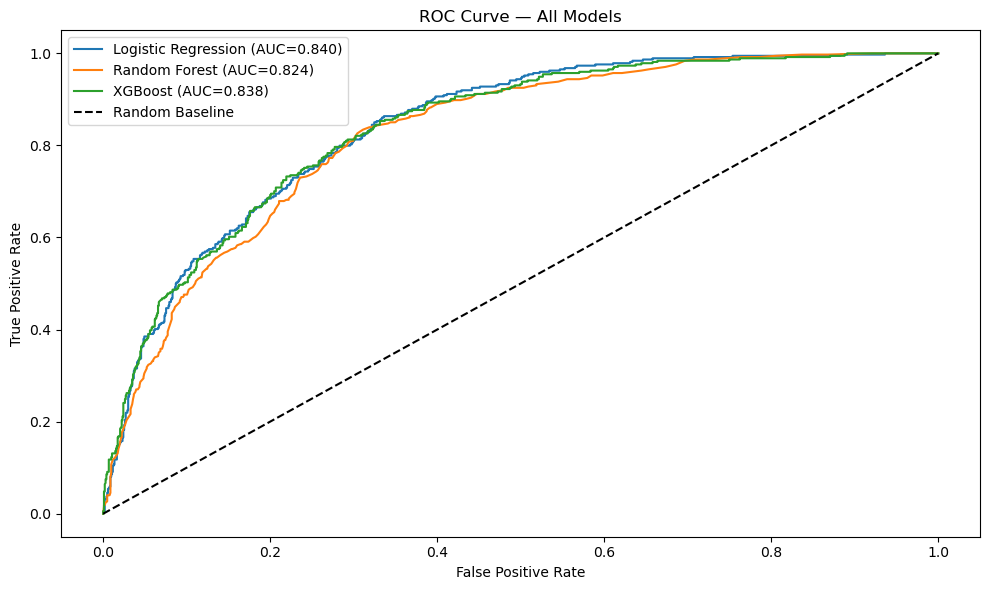

In [7]:
models = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'XGBoost':             xgb_model
}

plt.figure(figsize=(10, 6))
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*50}")
    print(f"{name} — ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred,
          target_names=['No Churn', 'Churned']))
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/roc_curve.png', dpi=150)
plt.show()

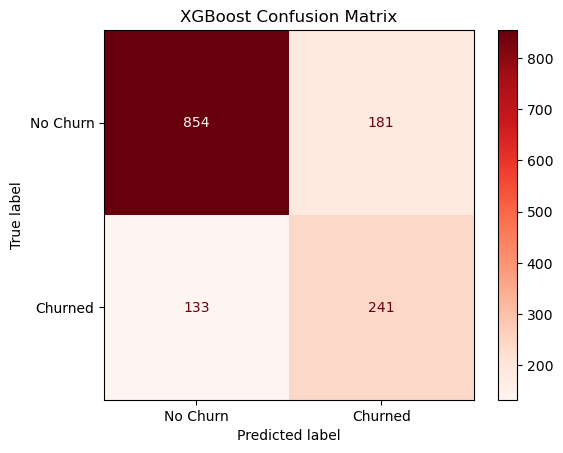

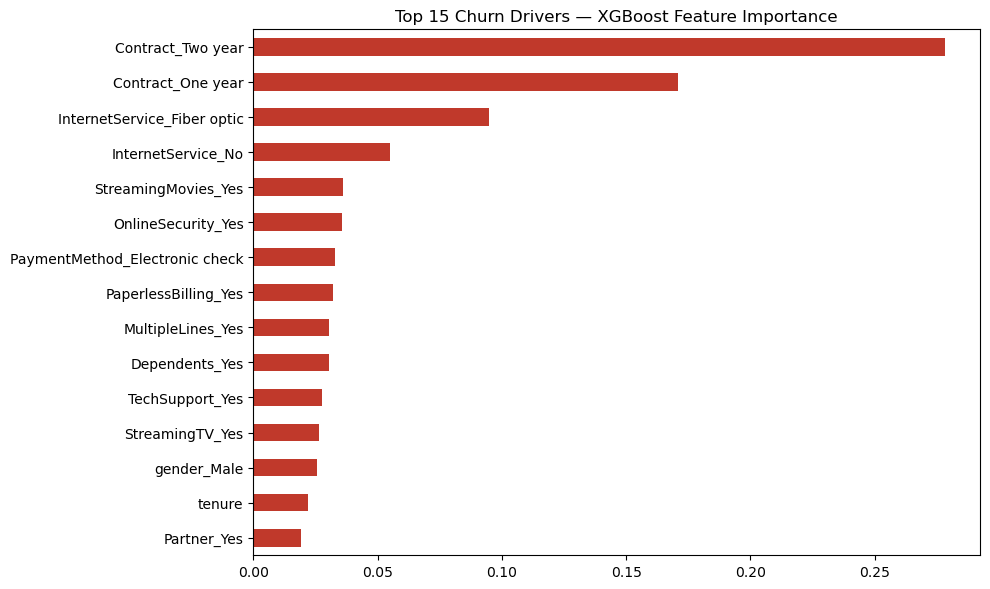

In [8]:
# Confusion Matrix — XGBoost
xgb_pred_test = xgb_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, xgb_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churned'])
disp.plot(cmap='Reds')
plt.title('XGBoost Confusion Matrix')
plt.savefig('../reports/confusion_matrix.png', dpi=150)
plt.show()

# Feature Importance (Top 15)
feat_imp = pd.Series(xgb_model.feature_importances_,
                      index=X.columns).sort_values().tail(15)
feat_imp.plot(kind='barh', figsize=(10, 6), color='#c0392b')
plt.title('Top 15 Churn Drivers — XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()

In [10]:
# Scale the entire feature set using the SAME scaler (already fit on train)
X_all_scaled = scaler.transform(X)

# Predict on entire dataset
all_proba     = xgb_model.predict_proba(X_all_scaled)[:, 1]
all_predicted = xgb_model.predict(X_all_scaled)

# ✅ Build the split label (Train / Test) for each row
split_label = pd.Series('Train', index=X.index)
split_label.loc[test_idx] = 'Test'

In [11]:
results = df.copy()
# Add model output columns
results['Churn_Probability'] = np.round(all_proba, 4)
results['Predicted_Churn']   = all_predicted
results['Split']             = split_label.values   # Train / Test flag

# Risk tier
results['Risk_Level'] = pd.cut(results['Churn_Probability'],
                                bins=[0, 0.3, 0.6, 1.0],
                                labels=['Low', 'Medium', 'High'])

results.to_csv('../data/predictions/churn_predictions.csv', index=False)

print("✅ Predictions saved!")
print(f"   telco_cleaned rows   : {len(df)}")
print(f"   churn_predictions rows: {len(results)}")
print(f"\nSplit breakdown:\n{results['Split'].value_counts()}")
print(f"\nRisk Level breakdown:\n{results['Risk_Level'].value_counts()}")
print(f"\nSample output:")
print(results[['customerID','Churn','Churn_Binary',
               'Churn_Probability','Predicted_Churn',
               'Risk_Level','Split']].head(10))

✅ Predictions saved!
   telco_cleaned rows   : 7043
   churn_predictions rows: 7043

Split breakdown:
Split
Train    5634
Test     1409
Name: count, dtype: int64

Risk Level breakdown:
Risk_Level
Low       4000
High      1602
Medium    1441
Name: count, dtype: int64

Sample output:
   customerID Churn  Churn_Binary  Churn_Probability  Predicted_Churn  \
0  7590-VHVEG    No             0             0.6892                1   
1  5575-GNVDE    No             0             0.0223                0   
2  3668-QPYBK   Yes             1             0.4323                0   
3  7795-CFOCW    No             0             0.0315                0   
4  9237-HQITU   Yes             1             0.7826                1   
5  9305-CDSKC   Yes             1             0.9394                1   
6  1452-KIOVK    No             0             0.4707                0   
7  6713-OKOMC    No             0             0.2292                0   
8  7892-POOKP   Yes             1             0.7674        